# Working with complicated dataset

Your name: Ynha Nguyen

### Question 1

blast_results: https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv

Read in the data from the csv file above. Skip all the comment lines, create a header for the dataframe based on the fields list in the comment line that starts with **# Fields:**. Drop the first column `query acc.ver`. Set the `subject acc.ver` as the index of the dataframe. The last column of the dataframe should be `publications`. Show the first five rows of the resulting dataframe.

In [28]:
import pandas as pd

url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/blast_results.csv"

with pd.io.common.get_handle(url, "r") as f:
    lines = f.handle.readlines()

fields_line = [l for l in lines if "Fields:" in l][0]
fields_line = fields_line.strip().strip('"')
columns = [col.strip() for col in fields_line.split("Fields:")[1].strip().split(",")]
columns = [col for col in columns if col]

df = pd.read_csv(url, comment="#", header=None, usecols=range(15), names=columns)

df.columns = [col.strip().strip('"') for col in df.columns]
df = df.drop(columns=["query acc.ver"])
df = df.set_index("subject acc.ver")

for col in df.columns:
    df[col] = pd.to_numeric(df[col].astype(str).str.replace(",", ""), errors="coerce")

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications
subject acc.ver,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487.0,9.0
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947.0,47.0
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106.0,13.0
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319.0,41.0


### Question 2
What is the average number of publications?

In [29]:
avg_publications = df["publications"].mean()
print(f"Average number of publications: {avg_publications:.2f}")

Average number of publications: 26.99


### Question 3
List the `subject acc.ver` that has over 15,000 bonds.

In [30]:
### Your code here . . .
result = df[df["bonds"] > 15000]
print(result.index.tolist())

['AGK29621.1', 'AHG32084.1', '6G2J_H', 'YP_002791042.1', 'AGK29634.1', '0806162F', 'YP_009112408.1', 'YP_001876469.1', 'YP_009092269.1', 'AHG32149.1', 'YP_009092074.1', 'YP_009450474.1', 'YP_004123270.1', 'YP_009092073.1', 'AHZ60901.1', 'YP_004123350.1', 'YP_009453754.1', 'ADD46492.1', 'YP_007025968.1', 'YP_009453806.1', 'YP_007024956.1', 'ASM92364.1', 'YP_006073044.1', 'ASM92494.1', 'ADG95699.1', 'YP_004891275.1', 'YP_009166014.1', 'YP_009538416.1', 'YP_009414182.1', 'YP_009178854.1', 'YP_009414415.1', 'YP_009353908.1', 'YP_009093743.1', 'ABX45285.1', 'YP_009414156.1', 'YP_009414363.1']


### Question 4
Create a plot that shows the correlation between `% identity` and `% positives`.

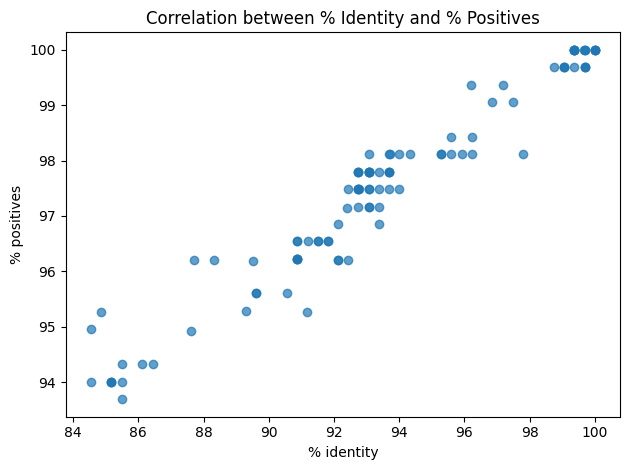

In [31]:
### Your code here . . .
import matplotlib.pyplot as plt

plt.scatter(df["% identity"], df["% positives"], alpha=0.7)
plt.xlabel("% identity")
plt.ylabel("% positives")
plt.title("Correlation between % Identity and % Positives")
plt.tight_layout()
plt.show()

### Question  5
Add a column `Protein source` to the dataframe from Question 1 based on the data in this csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv. Merge the data when the `subject acc.ver` from the dataframe equals to `Protein` in the csv file. Entries without a matching protein will have `NA` as `Protein source`.

In [33]:
### Your code here . . .
protein_url = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/protein_source.csv"
protein_df = pd.read_csv(protein_url)[["Protein", "Source"]]

df = df.merge(protein_df, left_index=True, right_on="Protein", how="left")

df = df.set_index("Protein")
df.index.name = "subject acc.ver"

df = df.rename(columns={"Source": "Protein source"})
df["Protein source"] = df["Protein source"].fillna("NA")

df.head()

,% identity,alignment length,mismatches,gap opens,q. start,q. end,s. start,s. end,evalue,bit score,% positives,bonds,publications,Protein source
subject acc.ver,,,,,,,,,,,,,,
NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NA
NP_904328.1,100.000,318.0,0.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,1487.0,9.0,RefSeq
AGK29621.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,629.0,100.00,17947.0,47.0,NA
YP_220563.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,100.00,12106.0,13.0,GenPept
ACM24502.1,99.686,318.0,1.0,0.0,1.0,318.0,1.0,318.0,0.0,627.0,99.69,2319.0,41.0,NA
